In [6]:
import torch 
from torch import nn
import torch.optim as optim
from data_tuning.data_utils import create_data_loaders
from cnn_utils import train, test, BaseCNN

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [2]:
data_dir = "c:/Users/tjagn/Desktop/chestxray/transformed/"
batch_size = 64
loss_fn = nn.CrossEntropyLoss()

In [3]:
dataloaders = create_data_loaders(data_dir, batch_size, 4)

In [4]:
cnn = BaseCNN()
cnn.to(device)

BaseCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU(inplace=True)
  )
  (pool3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=30752, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [ ]:
optimizer = optim.Adam(cnn.parameters(), lr=0.001, weight_decay=1e-4)
train(cnn, dataloaders[0], dataloaders[1], optimizer, loss_fn, 30, batch_size, device=device)

KeyboardInterrupt: 


--- Test Results ---
Loss:      3.6837
Accuracy:  66.35%
Precision: 0.7321
Recall:    0.6635
F1 Score:  0.6485


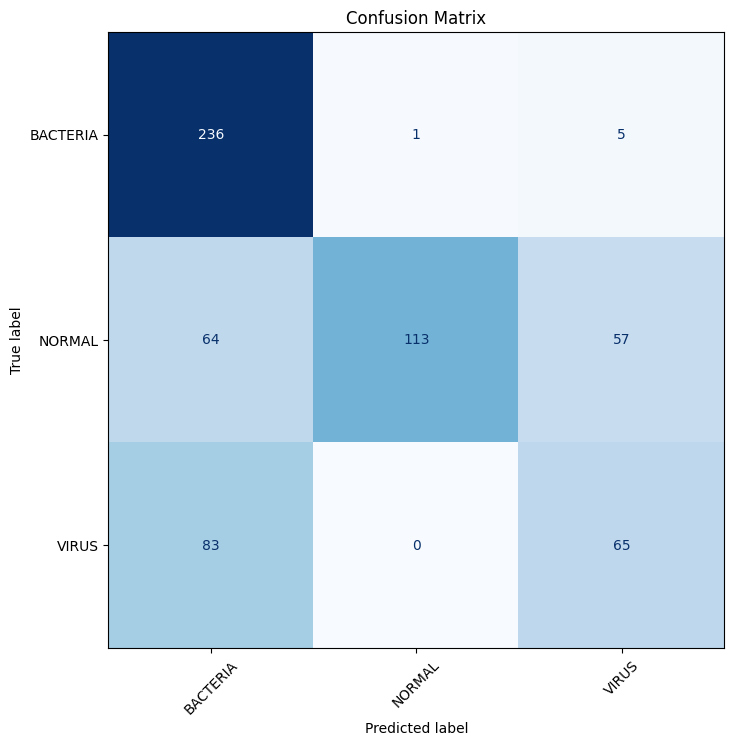

In [12]:
test(cnn, dataloaders[2], loss_fn, device)